In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers

# Load the image
image_path = '/content/leaf.jpg'
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize image to the desired input size of the model
target_size = (256, 256) # Changed to match model input size
image_resized = cv2.resize(image_rgb, target_size)

In [ ]:
# Normalize the image
image_normalized = image_resized / 255.0
# Add batch dimension
image_batch = np.expand_dims(image_normalized, axis=0)
# UNet Model Definition (You can also use a pre-trained model)
def build_unet_model(input_size=(256, 256, 3)):
  inputs = layers.Input(input_size)
# Encoder
  c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
  c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c1)
  p1 = layers.MaxPooling2D((2, 2))(c1)
  c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p1)
  c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c2)
  p2 = layers.MaxPooling2D((2, 2))(c2)

  c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p2)
  c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c3)
  p3 = layers.MaxPooling2D((2, 2))(c3)
# Bottleneck
  c4 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p3)
  c4 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c4)

 # Decoder
  u5 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c4)
  u5 = layers.concatenate([u5, c3])
  c5 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u5)
  c5 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c5)

  u6 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c5)
  u6 = layers.concatenate([u6, c2])
  c6 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u6)
  c6 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c6)
  u7 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c6)
  u7 = layers.concatenate([u7, c1])
  c7 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(u7)
  c7 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c7)
  outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c7)
  model = tf.keras.Model(inputs=[inputs], outputs=[outputs])
  return model
model = build_unet_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 64, 64,    │    131,200 │ conv2d_7[0][0]    │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 256)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │    295,040 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_8[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 128, 128,  │     32,832 │ conv2d_9[0][0]  

 Total params: 1,925,601 (7.35 MB)

 Trainable params: 1,925,601 (7.35 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])
# Example: model.fit(x_train, y_train, epochs=10, batch_size=2, validation_split=0.1)
# For demonstration, we will assume the model is already trained.

In [ ]:
x_train = np.random.rand(5, 256, 256, 3)
y_train = np.random.randint(0, 2, (5, 256, 256, 1))
model.fit(x_train, y_train, epochs=50, batch_size=1, validation_split=0.2,verbose=1)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.4998 - loss: 0.6933 - val_accuracy: 0.5013 - val_loss: 0.6931
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5007 - loss: 0.6932 - val_accuracy: 0.4983 - val_loss: 0.6932
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.5030 - loss: 0.6931 - val_accuracy: 0.5020 - val_loss: 0.6931
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.5054 - loss: 0.6931 - val_accuracy: 0.4991 - val_loss: 0.6932
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5068 - loss: 0.6931 - val_accuracy: 0.5002 - val_loss: 0.6932
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.5077 - loss: 0.6930 - val_accuracy: 0.5005 - val_loss: 0.6931
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5094 - loss: 0.6930 - val_accuracy: 0.5019 - val_loss: 0.6932
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.5117 - loss: 0.6929 - val_accuracy: 0.5006 - val_loss: 0.6932
Epoch 9/50
4

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 585ms/step


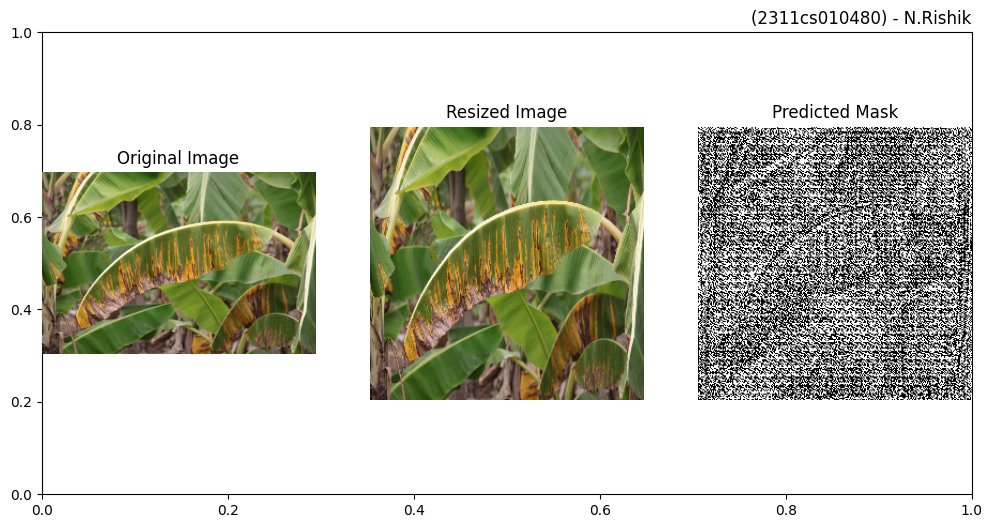

In [ ]:
# Make a prediction
prediction = model.predict(image_batch)
# Post-process the prediction
predicted_mask = np.squeeze(prediction) # Remove batch dimension
predicted_mask = np.round(predicted_mask) # Binarize the mask
# Display the result
plt.figure(figsize=(12, 6))
plt.title('(2311cs010480) - N.Rishik',loc='right')
plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(image_rgb)
plt.axis('off')
plt.subplot(1, 3, 2)
plt.title('Resized Image')
plt.imshow(image_resized)
plt.axis('off')
plt.subplot(1, 3, 3)
plt.title('Predicted Mask')
plt.imshow(predicted_mask, cmap='gray')
plt.axis('off')
plt.show()